# __FX Intelligent__

Names:  
- Abigail Chirinos Espejel  
- Ivonne Castañeda Chavarria  

__Final Project__

Date: 28/Agosto/2026  

Fuente de Datos y Alcance del Dataset

La base de datos contiene información histórica sobre los tipos de cambio entre el Peso Mexicano (MXN) y tres de las principales divisas internacionales: Dólar Estadounidense (USD), Euro (EUR) y Libra Esterlina (GBP).

El análisis comprende el periodo del 02/01/2015 al 23/09/2026, considerando únicamente días hábiles en México.

Los datos de los tipos de cambio fueron obtenidos de fuentes financieras oficiales y confiables, con el objetivo de garantizar la consistencia y precisión de la información utilizada durante el análisis.


| Característica | Description |
|:--------|:------------|
| Fecha Inicial | 02/01/2015 |
| Fecha Final | 23/09/2026 |
| Frecuencia | Daily |
| Calendario | Mexican business days only |
| Moneda Destino | Mexican Peso (MXP) |
| Moneda de Origen | USD, EUR, GBP |  


¿Por qué se seleccionó este periodo?
El periodo comprendido entre 2015 y 2026 proporciona más de diez años de información histórica sobre los tipos de cambio, lo que permite analizar su comportamiento bajo diferentes condiciones económicas e identificar periodos de mayor volatilidad.

Propósito del dataset
La base de datos será utilizada para analizar el comportamiento histórico de los tipos de cambio, identificar tendencias y patrones, comparar el comportamiento de las tres divisas frente al Peso Mexicano y servir como base para el desarrollo del análisis de FX Intelligence.


In [1]:
# Charge the necesary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Charged the dataset from 02/01/2015 al 23/09/2026

TC = pd.read_csv("TipoCambio_20150101_20260923.csv")

In [3]:
# Checking the first 5 rows of the dataset
TC.head()

,tmb_FechaCarga,tmb_MonedaDest,tmb_MonedaOrig,tmb_PrecioLimpio
0,20260923,MXP,EUR,19.935626
1,20260923,MXP,GBP,23.187456
2,20260923,MXP,USD,17.511200
3,20260922,MXP,EUR,19.794050
4,20260922,MXP,GBP,23.070590


## EDA

In [4]:
# Data types
TC.dtypes

tmb_FechaCarga        int64
tmb_MonedaDest          str
tmb_MonedaOrig          str
tmb_PrecioLimpio    float64
dtype: object

In [5]:
# Checking the missings
TC.isnull().sum()

tmb_FechaCarga      0
tmb_MonedaDest      0
tmb_MonedaOrig      0
tmb_PrecioLimpio    0
dtype: int64

In [6]:
# Checking the duplicated values

TC.duplicated().sum()

np.int64(0)

In [7]:
# Checking our dataset, as number of rows and columns

TC.shape

(8715, 4)

In [8]:
# Currencies in the dataset
TC.groupby(["tmb_MonedaOrig", "tmb_MonedaDest"]
).size().reset_index(name="Count")

,tmb_MonedaOrig,tmb_MonedaDest,Count
0,EUR,MXP,2905
1,GBP,MXP,2905
2,USD,MXP,2905


In [9]:
# Now we want to know the dates in our dataset.

TC["tmb_FechaCarga"].min(), TC["tmb_FechaCarga"].max()

(np.int64(20150102), np.int64(20260923))

In [10]:
# Changing the date format to datetime

TC["tmb_FechaCarga"] = pd.to_datetime(TC["tmb_FechaCarga"].astype(str),format="%Y%m%d")
TC.dtypes

tmb_FechaCarga      datetime64[us]
tmb_MonedaDest                 str
tmb_MonedaOrig                 str
tmb_PrecioLimpio           float64
dtype: object

In [11]:
# Checking the statistics of the dataset by tmb_MonedaOrig 

TC.groupby("tmb_MonedaOrig")["tmb_PrecioLimpio"].describe()

,count,mean,std,min,25%,50%,75%,max
tmb_MonedaOrig,,,,,,,,
EUR,2905.0,21.226938,2.122440,16.021204,19.880813,21.245595,22.435700,27.026854
GBP,2905.0,24.925262,1.992865,20.619497,23.410076,24.866211,26.127564,30.916438
USD,2905.0,18.904216,1.682820,14.555900,17.769400,18.926500,20.029500,25.145000


In [12]:
# Checking the number of unique dates for each currency in the dataset

TC.groupby("tmb_MonedaOrig")["tmb_FechaCarga"].nunique()

tmb_MonedaOrig
EUR    2905
GBP    2905
USD    2905
Name: tmb_FechaCarga, dtype: int64

Lo que observamos en la base de datos es que contiene un total de *8,715 observaciones*, de los cuales tenemos *2,905 datos* por divisa. En ésta misma no se encontraron valores nulos, registros duplicados, solamente tuvimos que modificar el formato de la fecha ya que no se encontraba en el formato correcto. 
La base de datos presenta una estructura consistente.

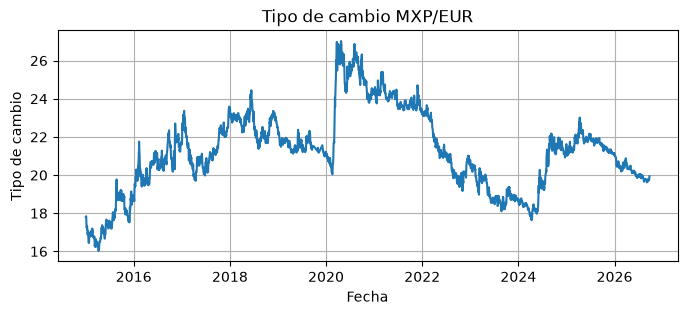

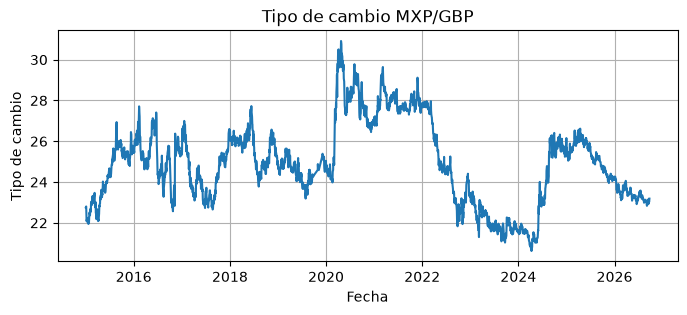

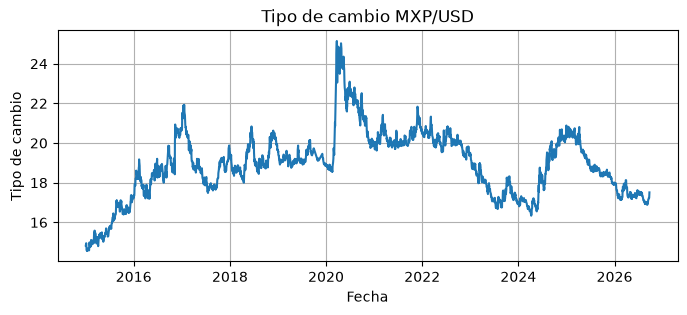

In [13]:
#Observamos en gráfica la evolución de tc

for divisa in TC["tmb_MonedaOrig"].unique():
    datos = TC[TC["tmb_MonedaOrig"] == divisa]
    plt.figure(figsize=(8, 3))
    plt.plot(datos["tmb_FechaCarga"], datos["tmb_PrecioLimpio"])
    plt.title(f"Tipo de cambio MXP/{divisa}")
    plt.xlabel("Fecha")
    plt.ylabel("Tipo de cambio")
    plt.grid(True)
    plt.show()

Podemos observar que tienen varios periodos similares, se presentan cambios importantes en 2020, muestran una caída posteriormente y una recuperación hasta 2024-2025 y por último muestran una tendencia descendente.

In [14]:
# Calculamos el rendimiento diario

TTC = TC.sort_values(["tmb_MonedaOrig", "tmb_FechaCarga"]).copy()

TC["Rendimiento"] = (TC.groupby("tmb_MonedaOrig")["tmb_PrecioLimpio"].pct_change())

# Eliminamos únicamente las observaciones sin rendimiento
TC = TC.dropna(subset=["Rendimiento"]).copy()

In [15]:
# Comprobamos la nueva variable
TC.groupby("tmb_MonedaOrig")["Rendimiento"].count()

tmb_MonedaOrig
EUR    2904
GBP    2904
USD    2904
Name: Rendimiento, dtype: int64

**Cálculo de rendimiento diario**

El cálculo del rendimiento se realizó mediante la siguiente formúla:

$$
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
$$

donde $P_t$ representa el tipo de cambio en el día $t$.

La primera observación de cada serie no cuenta con un valor previo para realizar el cálculo, por lo que se eliminaron.

In [16]:
# Revisamos el comportamiento de los rendimientos

TC.groupby("tmb_MonedaOrig")["Rendimiento"].describe()

,count,mean,std,min,25%,50%,75%,max
tmb_MonedaOrig,,,,,,,,
EUR,2904.0,-0.000009,0.007778,-0.070226,-0.003993,0.000247,0.004379,0.031112
GBP,2904.0,0.000024,0.007826,-0.080646,-0.004231,0.000253,0.004451,0.045184
USD,2904.0,-0.000028,0.007652,-0.078199,-0.004097,0.000242,0.004241,0.040395


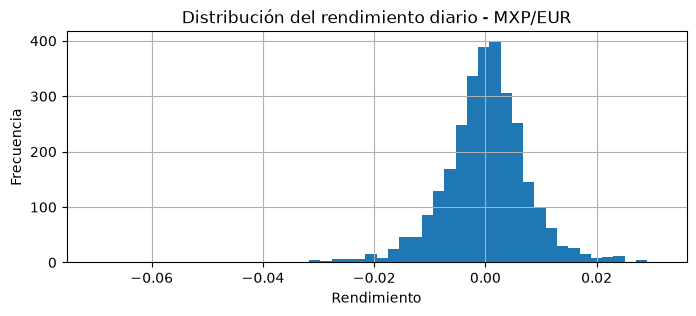

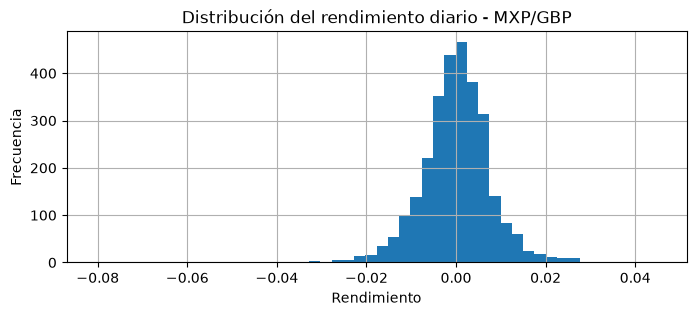

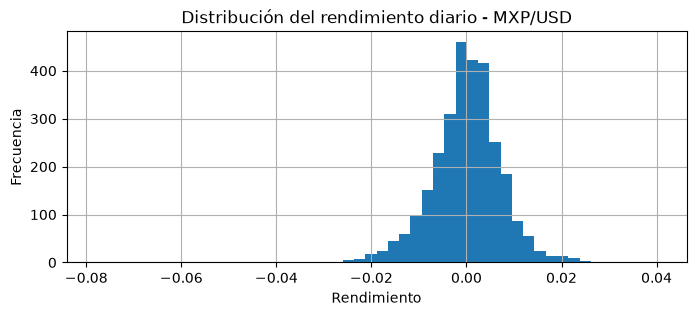

In [17]:
# Graficamos el comportamiento de cada una de las divisas

for divisa in TC["tmb_MonedaOrig"].unique():
    datos = TC[TC["tmb_MonedaOrig"] == divisa]
    plt.figure(figsize=(8, 3))
    plt.hist(datos["Rendimiento"], bins=50)
    plt.title(f"Distribución del rendimiento diario - MXP/{divisa}")
    plt.xlabel("Rendimiento")
    plt.ylabel("Frecuencia")
    plt.grid(True)
    plt.show()

**Distribución de los rendimientos diarios**

Los histogramas muestran que los rendimientos diarios de las tres divisas se concentran alrededor de cero, se observa una dispersión relativamente pequeña en la mayor parte de las observaciones; esto indica la existencia de algunas variaciones diarias de mayor magnitud.

Los estadísticos descriptivos muestran desviaciones estándar cercanas a $0.008$ para los cruces de USD y GBP, para EUR cercanas a $0.006$, mientras que las medias se encuentran muy próximas a cero. Esto sugiere que el comportamiento del tipo de cambio presenta periodos de variación estables junto con episodios de movimientos diarios más pronunciados.

Los valores extremos no se eliminarán automáticamente, ya que podrían corresponder a movimientos reales del mercado y posteriormente podrán
ser analizados como parte del comportamiento de las series.

In [18]:
# Calculamos la volatilidad de 20 días 

TC["Vola20"] = (TC.groupby("tmb_MonedaOrig")["Rendimiento"].transform(lambda x: x.rolling(20).std()))

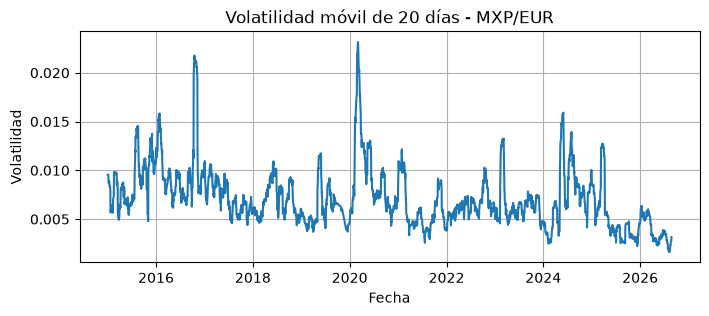

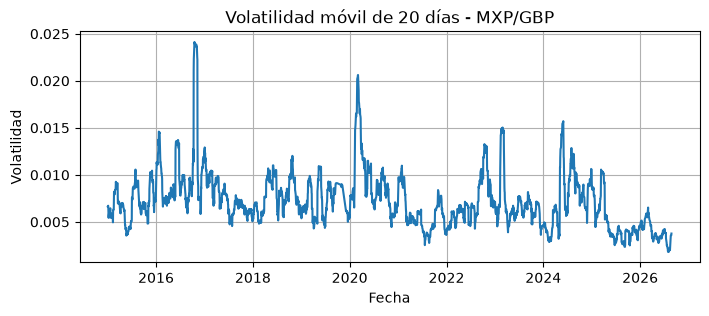

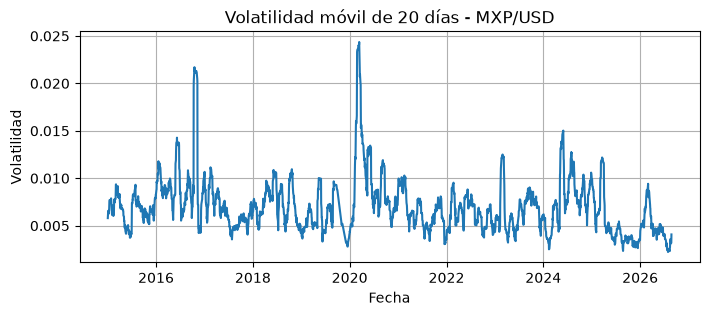

In [19]:
# Graficamos la volatilidad

for divisa in TC["tmb_MonedaOrig"].unique():
    datos = TC[TC["tmb_MonedaOrig"] == divisa]
    plt.figure(figsize=(8, 3))
    plt.plot(datos["tmb_FechaCarga"], datos["Vola20"])
    plt.title(f"Volatilidad móvil de 20 días - MXP/{divisa}")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad")
    plt.grid(True)
    plt.show()

**Volatilidad**

Para poder analizar el tipo de cambio a lo largo del tiempo se calculo la volatilidad móvil de 20 días utilizando la desviación estándar de los rendimientos.

$$
\sigma_{t,20} =
\sqrt{
\frac{1}{19}
\sum_{i=0}^{19}
(R_{t-i}-\bar{R}_{t,20})^2
}
$$

donde $R_t$ representa el rendimiento diario y $\bar{R}_{t,20}$ es el rendimiento promedio de los últimos 20 días hábiles.

Las gráficas muestran que la volatilidad cambia a lo largo del tiempo y se observan incrementos de volatilidad que aparecen de manera similar entre las tres divisas.

Esta variable será utilizada posteriormente como una característica (*feature*) para el análisis y modelos predictivos.

In [20]:
# Calcularemos la correlación de las divisas entre sus rendimientos

TC.pivot(index="tmb_FechaCarga", columns="tmb_MonedaOrig", values="Rendimiento").corr()

tmb_MonedaOrig,EUR,GBP,USD
tmb_MonedaOrig,,,
EUR,1.000000,0.819085,0.793233
GBP,0.819085,1.000000,0.712225
USD,0.793233,0.712225,1.000000


**Correlación entre divisas**

Para analizar la relación entre los movimientos diarios de las divisas se calculó la matriz de correlación de los rendimientos.

Observando los resultados, las tres relaciones presentan una correlación positiva, lo que indica que los rendimientos tienden a presentar movimientos en la misma dirección. La correlación más alta se observa entre *EUR* y *GBP*, la menor se presenta entre *GBP* y *USD*.

La correlación representa una asociación lineal y no implica causalidad, estos resultados pueden ser utilizados posteriormente para evaluar si los movimientos de otras monedas aportan información útil como variables predictoras.

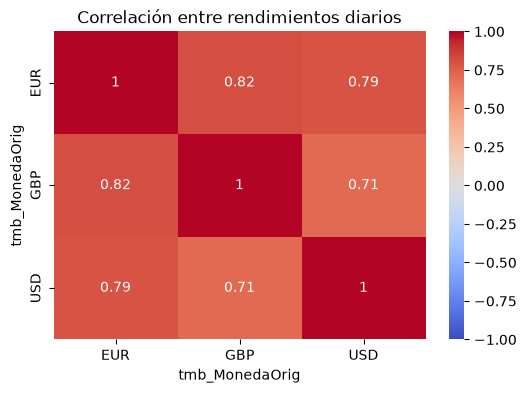

In [21]:
import seaborn as sns

rendimientos = TC.pivot(index="tmb_FechaCarga", columns="tmb_MonedaOrig", values="Rendimiento")

plt.figure(figsize=(6, 4))

sns.heatmap(
    rendimientos.corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlación entre rendimientos diarios")
plt.show()

In [22]:
# Revisaremos la volatilidad por divisa
TC.groupby("tmb_MonedaOrig")["Rendimiento"].std().sort_values(ascending=False)

tmb_MonedaOrig
GBP    0.007826
EUR    0.007778
USD    0.007652
Name: Rendimiento, dtype: float64

¿Existen diferencias significativas en la volatilidad de los rendimientos entre USD, EUR y GBP frente al peso mexicano?

In [23]:
# Revisamos la volatilidad histórica por divisa
volatilidad_divisa = (TC.groupby("tmb_MonedaOrig")["Rendimiento"].std().sort_values(ascending=False))

volatilidad_divisa

tmb_MonedaOrig
GBP    0.007826
EUR    0.007778
USD    0.007652
Name: Rendimiento, dtype: float64

In [24]:
(volatilidad_divisa * 100).round(3)

tmb_MonedaOrig
GBP    0.783
EUR    0.778
USD    0.765
Name: Rendimiento, dtype: float64

### Volatilidad histórica por divisa

La desviación estándar de los rendimientos diarios se utilizó como una medida descriptiva de volatilidad para comparar las tres divisas.

Los resultados muestran que **GBP presentó la mayor volatilidad diaria (0.783%)**, seguida por **EUR (0.778%)** y **USD (0.765%)**.

Aunque GBP presenta la mayor desviación estándar, las diferencias observadas entre las tres divisas son pequeñas. Por lo tanto, este análisis permite describir su comportamiento histórico, pero no permite concluir todavía que existan diferencias estadísticamente significativas en su volatilidad.

In [25]:
# Calculamos el movimiento absoluto del rendimiento
TC["Rendimiento_Abs"] = TC["Rendimiento"].abs()

In [26]:
# Identificamos los 5 movimientos diarios más extremos por divisa
movimientos_extremos = (TC.sort_values(["tmb_MonedaOrig", "Rendimiento_Abs"],
        ascending=[True, False]
    )
    .groupby("tmb_MonedaOrig")
    .head(5)
)

movimientos_extremos[
    [
        "tmb_FechaCarga",
        "tmb_MonedaOrig",
        "tmb_PrecioLimpio",
        "Rendimiento"
    ]
]

,tmb_FechaCarga,tmb_MonedaOrig,tmb_PrecioLimpio,Rendimiento
7314,2016-11-08,EUR,20.305642,-0.070226
4941,2020-03-06,EUR,22.829257,-0.052636
1743,2024-05-31,EUR,18.423223,-0.045842
4926,2020-03-13,EUR,24.308576,-0.042948
8022,2015-12-02,EUR,17.618766,-0.037942
7315,2016-11-08,GBP,22.836247,-0.080646
4942,2020-03-06,GBP,26.258358,-0.047875
1744,2024-05-31,GBP,21.609003,-0.047046
7603,2016-06-23,GBP,27.098937,0.045184
4903,2020-03-26,GBP,28.170948,-0.039517


In [27]:
# Queremos conocer las subidas y bajadas de cadadivisa
TC["Direccion"] = TC["Rendimiento"].apply(lambda x: "Subida" if x > 0 else "Bajada")

In [28]:
TC["Direccion"].value_counts()

Direccion
Subida    4503
Bajada    4209
Name: count, dtype: int64

In [29]:
#CCon esto obtendremos la subida y bajada por divisa
TC.groupby(["tmb_MonedaOrig", "Direccion"]).size().unstack()

Direccion,Bajada,Subida
tmb_MonedaOrig,,
EUR,1397,1507
GBP,1407,1497
USD,1405,1499


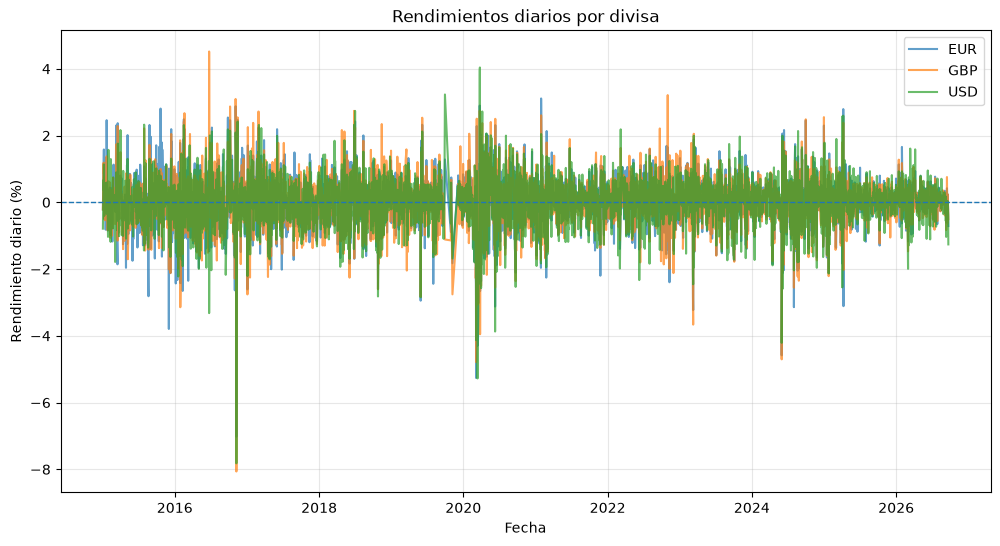

In [30]:
#Ahora nos interesa ver las subidas y bajadas, graficamente, lo que nos permitira ver si existen outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for moneda in TC["tmb_MonedaOrig"].unique():
    
    datos = TC[TC["tmb_MonedaOrig"] == moneda]
    
    plt.plot(
        datos["tmb_FechaCarga"],
        datos["Rendimiento"] * 100,
        label=moneda,
        alpha=0.7
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Rendimientos diarios por divisa")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento diario (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Lo que observamos de la gr+afica anterior son los rendimientos de las tres divisas están concentrados alrededor de 0% durante la mayor parte del periodo. Es decir, los cambios diarios suelen ser relativamente pequeños.

También se observan picos positivos y negativos en momentos específicos. Visualmente destacan especialmente periodos alrededor de 2016–2017, 2020 y 2024–2025.

In [31]:
# Top 5 movimientos extremos por divisa

movimientos_extremos = (TC.sort_values(["tmb_MonedaOrig", "Rendimiento_Abs"], ascending=[True, False])
    .groupby("tmb_MonedaOrig")
    .head(5)
    .copy())

movimientos_extremos["Rendimiento_%"] = (movimientos_extremos["Rendimiento"] * 100).round(2)

movimientos_extremos[
    [
        "tmb_FechaCarga",
        "tmb_MonedaOrig",
        "tmb_PrecioLimpio",
        "Rendimiento_%"
    ]
]

,tmb_FechaCarga,tmb_MonedaOrig,tmb_PrecioLimpio,Rendimiento_%
7314,2016-11-08,EUR,20.305642,-7.02
4941,2020-03-06,EUR,22.829257,-5.26
1743,2024-05-31,EUR,18.423223,-4.58
4926,2020-03-13,EUR,24.308576,-4.29
8022,2015-12-02,EUR,17.618766,-3.79
7315,2016-11-08,GBP,22.836247,-8.06
4942,2020-03-06,GBP,26.258358,-4.79
1744,2024-05-31,GBP,21.609003,-4.70
7603,2016-06-23,GBP,27.098937,4.52
4903,2020-03-26,GBP,28.170948,-3.95


## Estadistica

In [32]:
# Estadísticas descriptivas de los rendimientos por divisa

estadisticas = (TC.groupby("tmb_MonedaOrig")["Rendimiento"].agg(
          Media="mean",
          Mediana="median",
          Varianza="var",
          Desv_Estandar="std",
          Minimo="min",
          Maximo="max"))

estadisticas

,Media,Mediana,Varianza,Desv_Estandar,Minimo,Maximo
tmb_MonedaOrig,,,,,,
EUR,-0.000009,0.000247,0.000061,0.007778,-0.070226,0.031112
GBP,0.000024,0.000253,0.000061,0.007826,-0.080646,0.045184
USD,-0.000028,0.000242,0.000059,0.007652,-0.078199,0.040395


In [33]:
estadisticas_pct = estadisticas.copy()

columnas_pct = [
    "Media",
    "Mediana",
    "Desv_Estandar",
    "Minimo",
    "Maximo"
]

estadisticas_pct[columnas_pct] = (
    estadisticas_pct[columnas_pct] * 100
)

estadisticas_pct.round(4)

,Media,Mediana,Varianza,Desv_Estandar,Minimo,Maximo
tmb_MonedaOrig,,,,,,
EUR,-0.0009,0.0247,0.0001,0.7778,-7.0226,3.1112
GBP,0.0024,0.0253,0.0001,0.7826,-8.0646,4.5184
USD,-0.0028,0.0242,0.0001,0.7652,-7.8199,4.0395


In [34]:
# Ahora calculemos los intervalos de confianza
import numpy as np
from scipy import stats

resultados_ic = []

for moneda, grupo in TC.groupby("tmb_MonedaOrig"):
    
    datos = grupo["Rendimiento"].dropna()
    
    n = len(datos)
    media = datos.mean()
    error_std = stats.sem(datos)
    
    ic = stats.t.interval(
        confidence=0.95,
        df=n - 1,
        loc=media,
        scale=error_std
    )
    
    resultados_ic.append({
        "Divisa": moneda,
        "Media": media,
        "IC_Inferior": ic[0],
        "IC_Superior": ic[1]
    })

In [35]:
#Ahora se mostrará la informacioon con 
IC = pd.DataFrame(resultados_ic)

IC[["Media", "IC_Inferior", "IC_Superior"]] *= 100

IC.round(4)

,Divisa,Media,IC_Inferior,IC_Superior
0,EUR,-0.0009,-0.0292,0.0274
1,GBP,0.0024,-0.0261,0.0309
2,USD,-0.0028,-0.0306,0.0251


### Interpretación de los intervalos de confianza

Los intervalos de confianza del **95%** para el rendimiento diario medio de **EUR, GBP y USD** incluyen el valor **0%**.

Esto indica que, considerando la incertidumbre de las estimaciones, no existe evidencia suficiente para afirmar que el rendimiento diario medio de alguna de las tres divisas sea diferente de cero durante el periodo analizado.

Aunque **GBP** presenta la media estimada más alta (**0.0024%**), seguida de **EUR (-0.0009%)** y **USD (-0.0028%)**, las diferencias observadas son pequeñas y los intervalos de confianza muestran que las estimaciones son compatibles con un rendimiento medio cercano a cero.

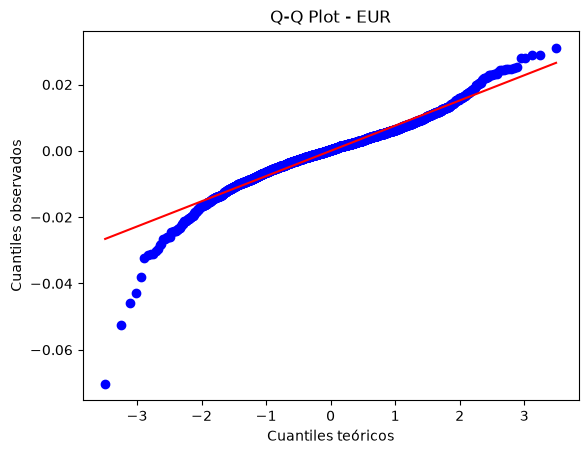

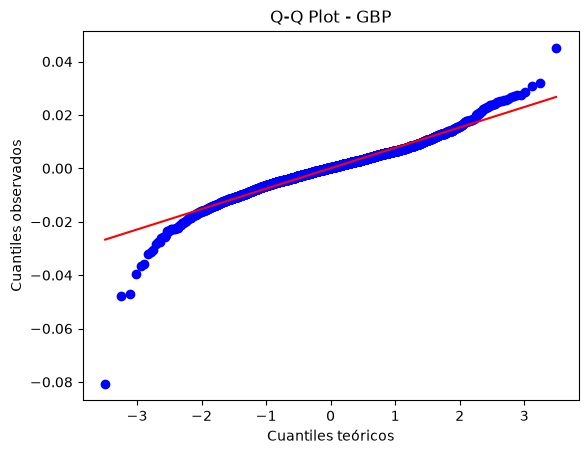

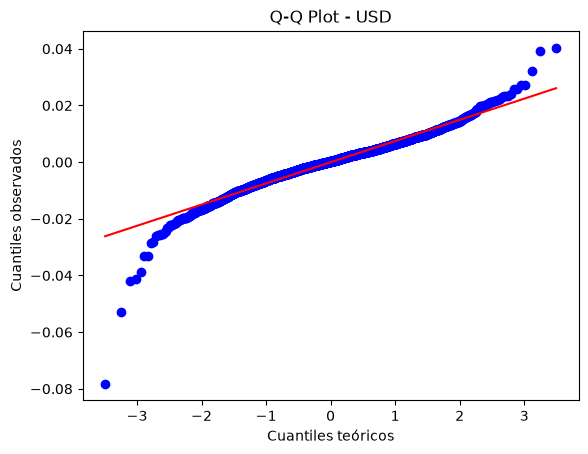

In [36]:
#Ahora veamos la distribución de los rendimientos por divisa, para ello utilizaremos un Q-Q plot, que nos permitirá ver si los rendimientos se distribuyen normalmente.
import matplotlib.pyplot as plt

for moneda in ["EUR", "GBP", "USD"]:
    
    datos = TC.loc[
        TC["tmb_MonedaOrig"] == moneda,
        "Rendimiento"
    ].dropna()

    stats.probplot(datos, dist="norm", plot=plt)

    plt.title(f"Q-Q Plot - {moneda}")
    plt.xlabel("Cuantiles teóricos")
    plt.ylabel("Cuantiles observados")
    plt.show()

### Evaluación de normalidad mediante Q-Q Plots

Los Q-Q plots muestran que los rendimientos de **EUR, GBP y USD** siguen aproximadamente la línea teórica de una distribución normal en la zona central. Sin embargo, se observan desviaciones importantes en los extremos de las tres distribuciones.

Por lo tanto, no se considera adecuado asumir normalidad completa en los rendimientos diarios. Este resultado será considerado para seleccionar las pruebas estadísticas utilizadas en la comparación entre divisas.

#### **¿Existen diferencias estadísticamente significativas en la distribución de los rendimientos diarios entre EUR, GBP y USD?**

### Comparación de los rendimientos entre divisas

Para determinar si existen diferencias estadísticamente significativas entre los rendimientos diarios de **EUR, GBP y USD**, se utilizará la **prueba de Friedman**.

Esta prueba no paramétrica es apropiada para comparar tres o más muestras relacionadas. En este caso, los rendimientos de las tres divisas están asociados por fecha y el análisis de los Q-Q plots mostró desviaciones de
normalidad en las colas.

#### Hipótesis

- **H₀ (Hipótesis nula):** No existen diferencias en la distribución de los rendimientos diarios entre EUR, GBP y USD.

- **H₁ (Hipótesis alternativa):** Al menos una de las divisas presenta una distribución de rendimientos diferente.

Se utilizará un nivel de significancia de **α = 0.05**.

In [37]:
#Primero realizaremos una alineación de los datos por fecha

rendimientos_pivot = TC.pivot(
    index="tmb_FechaCarga",
    columns="tmb_MonedaOrig",
    values="Rendimiento")

rendimientos_pivot.head()

tmb_MonedaOrig,EUR,GBP,USD
tmb_FechaCarga,,,
2015-01-02,-0.002112,-0.002198,-0.007888
2015-01-05,0.007258,0.011774,0.006668
2015-01-06,0.011726,0.008754,0.003671
2015-01-07,0.015825,0.011865,0.011362
2015-01-08,-0.001015,-0.001308,0.003224


In [38]:
#Ahor corrobaremos si no existen valores nulos en la tabla pivotada
rendimientos_pivot.isnull().sum()

tmb_MonedaOrig
EUR    0
GBP    0
USD    0
dtype: int64

In [39]:
#Eliminaremos fechas con valores nulos para poder realizar el test de Friedman
rendimientos_completos = rendimientos_pivot[["EUR", "GBP", "USD"]].dropna()

rendimientos_completos.shape

(2904, 3)

In [40]:
#Ahora ejecutaremos Friedman test para ver si existen diferencias significativas entre los rendimientos de las divisas
from scipy.stats import friedmanchisquare

estadistico, p_value = friedmanchisquare(
    rendimientos_completos["EUR"],
    rendimientos_completos["GBP"],
    rendimientos_completos["USD"])

print(f"Estadístico de Friedman: {estadistico:.4f}")
print(f"p-value: {p_value:.4f}")

Estadístico de Friedman: 1.3037
p-value: 0.5211


### Resultado de la prueba de Friedman

La prueba de Friedman obtuvo los siguientes resultados:

> * **Estadístico de Friedman:** 1.3037
> * **p-value:** 0.5211
> * **Nivel de significancia (α):** 0.05

Dado que el **p-value (0.5211) es mayor que α (0.05)**, no se rechaza la hipótesis nula (**H₀**).

Por lo tanto, no existe evidencia estadísticamente significativa para afirmar que la distribución de los rendimientos diarios difiere entre **EUR, GBP y USD** durante el periodo analizado.

Aunque en el análisis descriptivo se observaron pequeñas diferencias en la volatilidad de las tres divisas, estas diferencias no implican necesariamente diferencias estadísticamente significativas en sus rendimientos.

## Series de Tiempo

Ahora analizaremos la evolucion temporal del los tipos de cambio de **EUR, GBP Y USD frente al peso mexicano**, identificando tendencias, patrones temporales, cambios de volatilidad y relaciones entre las observaciones presentes y pasadas.

In [41]:
# Ordenamos las observaciones por divisa y fecha

TC = TC.sort_values(["tmb_MonedaOrig", "tmb_FechaCarga"]).copy()

TC[["tmb_FechaCarga", "tmb_MonedaOrig", "tmb_PrecioLimpio", "Rendimiento"]].head()

,tmb_FechaCarga,tmb_MonedaOrig,tmb_PrecioLimpio,Rendimiento
8712,2015-01-02,EUR,17.806663,-0.002112
8709,2015-01-05,EUR,17.844357,0.007258
8706,2015-01-06,EUR,17.715772,0.011726
8703,2015-01-07,EUR,17.510445,0.015825
8700,2015-01-08,EUR,17.237660,-0.001015


In [42]:
# Verificamos que el rango este correcto y que no existan fechas duplicadas por divisa
TC.groupby("tmb_MonedaOrig").agg(
    Fecha_Inicial=("tmb_FechaCarga", "min"),
    Fecha_Final=("tmb_FechaCarga", "max"),
    Observaciones=("tmb_FechaCarga", "count"))

,Fecha_Inicial,Fecha_Final,Observaciones
tmb_MonedaOrig,,,
EUR,2015-01-02,2026-09-22,2904
GBP,2015-01-02,2026-09-22,2904
USD,2015-01-02,2026-09-22,2904


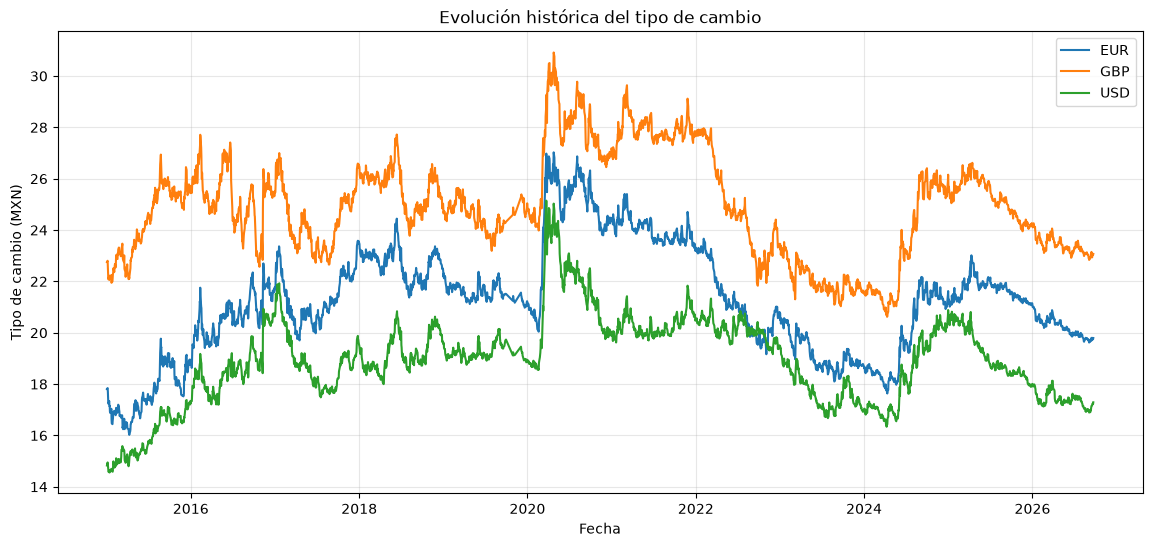

In [43]:
plt.figure(figsize=(14, 6))

for moneda in TC["tmb_MonedaOrig"].unique():
    
    datos = TC[TC["tmb_MonedaOrig"] == moneda]

    plt.plot(
        datos["tmb_FechaCarga"],
        datos["tmb_PrecioLimpio"],
        label=moneda
    )

plt.title("Evolución histórica del tipo de cambio")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio (MXN)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [44]:
#Ahora, revisaremos media móvil - Rolling Mean de 20 días para cada divisa
TC["Media_Movil_20"] = (
    TC.groupby("tmb_MonedaOrig")["tmb_PrecioLimpio"]
      .transform(lambda x: x.rolling(window=20).mean()))

In [45]:
TC[
    [
        "tmb_FechaCarga",
        "tmb_MonedaOrig",
        "tmb_PrecioLimpio",
        "Media_Movil_20"
    ]
].head(25)

,tmb_FechaCarga,tmb_MonedaOrig,tmb_PrecioLimpio,Media_Movil_20
8712,2015-01-02,EUR,17.806663,NaN
8709,2015-01-05,EUR,17.844357,NaN
8706,2015-01-06,EUR,17.715772,NaN
8703,2015-01-07,EUR,17.510445,NaN
8700,2015-01-08,EUR,17.237660,NaN
8697,2015-01-09,EUR,17.255174,NaN
8694,2015-01-12,EUR,17.338647,NaN
8691,2015-01-13,EUR,17.139573,NaN
8688,2015-01-14,EUR,17.152494,NaN
8685,2015-01-15,EUR,16.928360,NaN


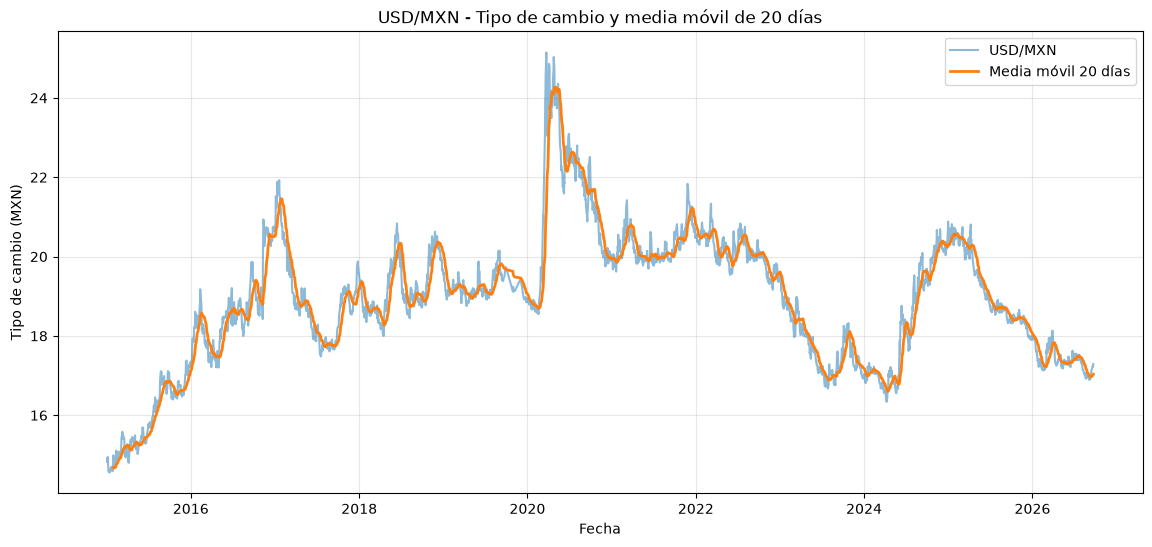

In [46]:
#Ahora graficaremos la volatilidad de 20 días para cada divisa
# ------------ USD ------------

usd = TC[TC["tmb_MonedaOrig"] == "USD"]

plt.figure(figsize=(14, 6))

plt.plot(
    usd["tmb_FechaCarga"],
    usd["tmb_PrecioLimpio"],
    label="USD/MXN",
    alpha=0.5
)

plt.plot(
    usd["tmb_FechaCarga"],
    usd["Media_Movil_20"],
    label="Media móvil 20 días",
    linewidth=2
)

plt.title("USD/MXN - Tipo de cambio y media móvil de 20 días")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio (MXN)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


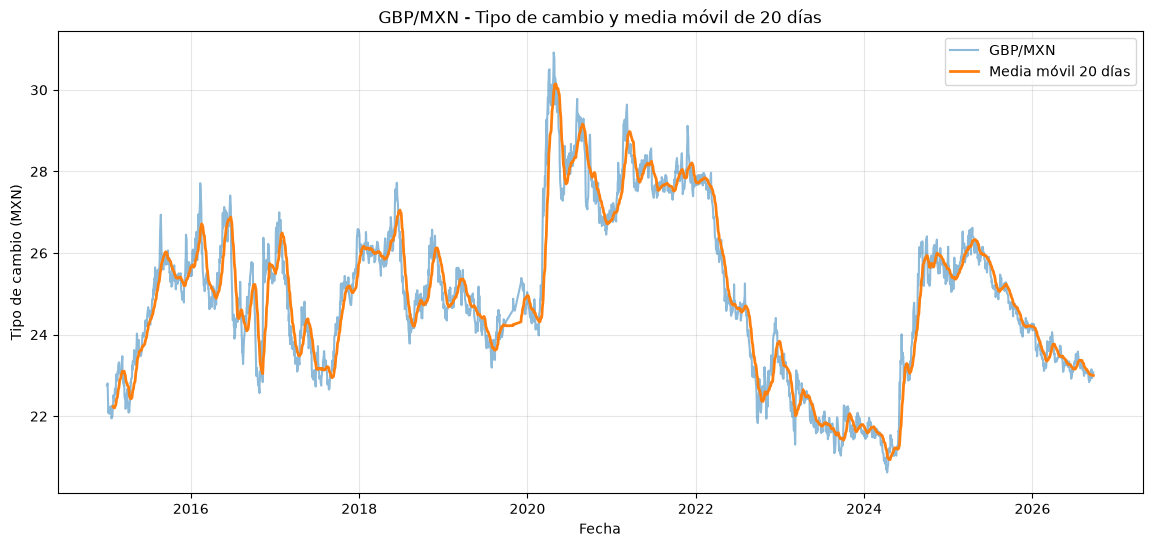

In [47]:
# ------------ GBP ------------

gbp = TC[TC["tmb_MonedaOrig"] == "GBP"]

plt.figure(figsize=(14, 6))

plt.plot(
    gbp["tmb_FechaCarga"],
    gbp["tmb_PrecioLimpio"],
    label="GBP/MXN",
    alpha=0.5
)

plt.plot(
    gbp["tmb_FechaCarga"],
    gbp["Media_Movil_20"],
    label="Media móvil 20 días",
    linewidth=2
)

plt.title("GBP/MXN - Tipo de cambio y media móvil de 20 días")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio (MXN)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

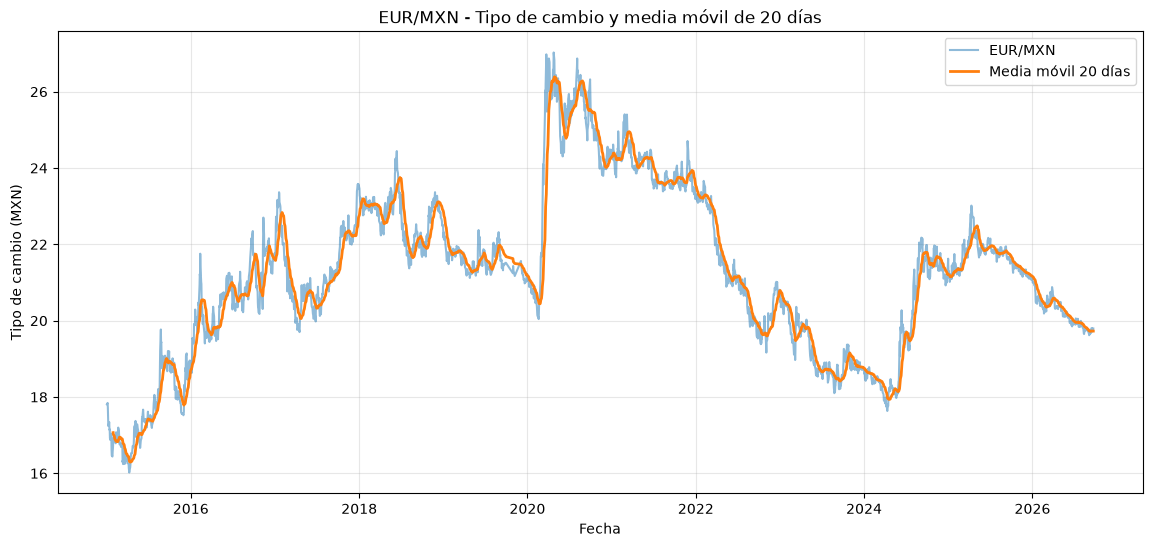

In [48]:
# ------------ EUR ------------
eur = TC[TC["tmb_MonedaOrig"] == "EUR"]

plt.figure(figsize=(14, 6))

plt.plot(
    eur["tmb_FechaCarga"],
    eur["tmb_PrecioLimpio"],
    label="EUR/MXN",
    alpha=0.5
)

plt.plot(
    eur["tmb_FechaCarga"],
    eur["Media_Movil_20"],
    label="Media móvil 20 días",
    linewidth=2
)

plt.title("EUR/MXN - Tipo de cambio y media móvil de 20 días")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio (MXN)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Realizaremos la comparación de la media móvil a 20 días y 60 días.

In [49]:
#Media móvil de 60 días para cada divisa
TC["Media_Movil_60"] = (
    TC.groupby("tmb_MonedaOrig")["tmb_PrecioLimpio"]
      .transform(lambda x: x.rolling(window=60).mean()))

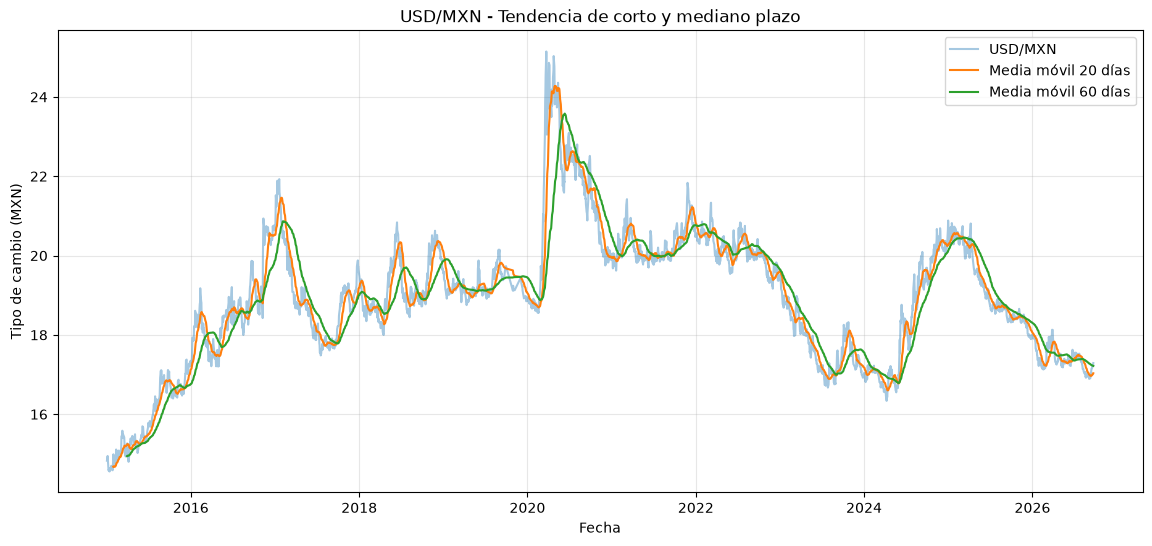

In [50]:
#Graficaremos la tendencia de corto y mediano plazo para el USD/MXN, utilizando las medias móviles de 20 y 60 días.
usd = TC[TC["tmb_MonedaOrig"] == "USD"]

plt.figure(figsize=(14, 6))

plt.plot(
    usd["tmb_FechaCarga"],
    usd["tmb_PrecioLimpio"],
    label="USD/MXN",
    alpha=0.4
)

plt.plot(
    usd["tmb_FechaCarga"],
    usd["Media_Movil_20"],
    label="Media móvil 20 días"
)

plt.plot(
    usd["tmb_FechaCarga"],
    usd["Media_Movil_60"],
    label="Media móvil 60 días"
)

plt.title("USD/MXN - Tendencia de corto y mediano plazo")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio (MXN)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

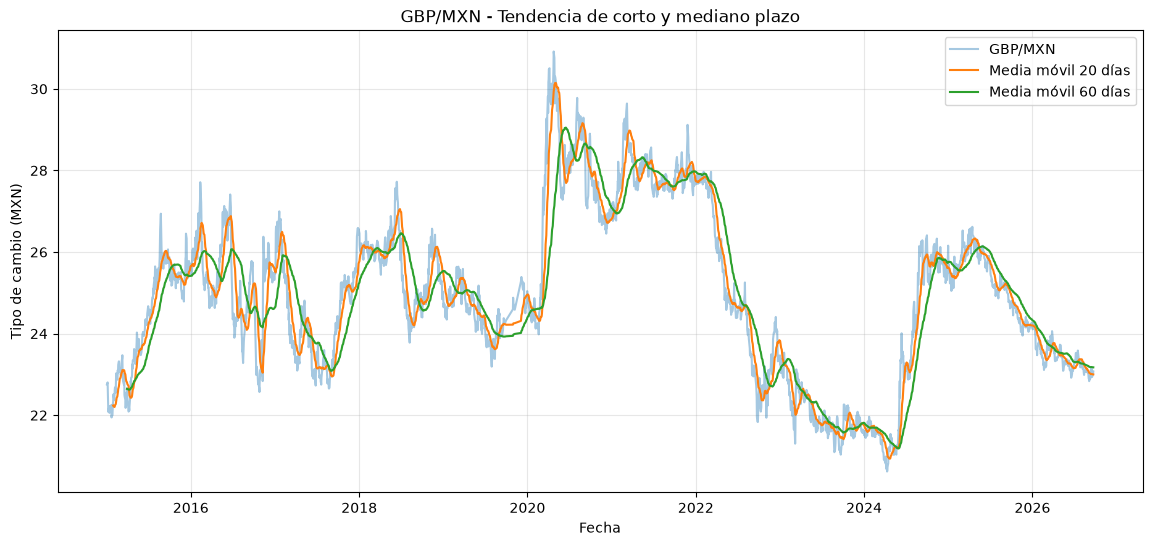

In [51]:
#Graficaremos la tendencia de corto y mediano plazo para el GBP/MXN, utilizando las medias móviles de 20 y 60 días.
gbp = TC[TC["tmb_MonedaOrig"] == "GBP"]

plt.figure(figsize=(14, 6))

plt.plot(
    gbp["tmb_FechaCarga"],
    gbp["tmb_PrecioLimpio"],
    label="GBP/MXN",
    alpha=0.4
)

plt.plot(
    gbp["tmb_FechaCarga"],
    gbp["Media_Movil_20"],
    label="Media móvil 20 días"
)

plt.plot(
    gbp["tmb_FechaCarga"],
    gbp["Media_Movil_60"],
    label="Media móvil 60 días"
)

plt.title("GBP/MXN - Tendencia de corto y mediano plazo")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio (MXN)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

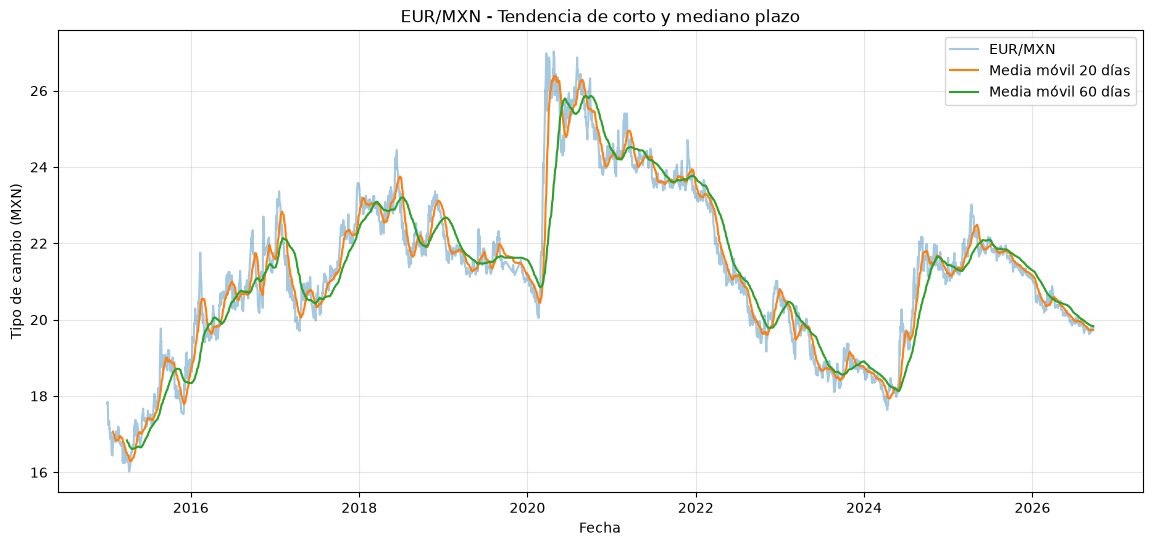

In [52]:
#Graficaremos la tendencia de corto y mediano plazo para el EUR/MXN, utilizando las medias móviles de 20 y 60 días.
eur = TC[TC["tmb_MonedaOrig"] == "EUR"]

plt.figure(figsize=(14, 6))

plt.plot(
    eur["tmb_FechaCarga"],
    eur["tmb_PrecioLimpio"],
    label="EUR/MXN",
    alpha=0.4
)

plt.plot(
    eur["tmb_FechaCarga"],
    eur["Media_Movil_20"],
    label="Media móvil 20 días"
)

plt.plot(
    eur["tmb_FechaCarga"],
    eur["Media_Movil_60"],
    label="Media móvil 60 días"
)

plt.title("EUR/MXN - Tendencia de corto y mediano plazo")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio (MXN)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Tendencia y medias móviles

Para analizar la tendencia de los tipos de cambio se calcularon medias móviles de **20 y 60 días hábiles**.

La media móvil de **20 días (MA20)** permite observar cambios de corto plazo y reacciona con mayor rapidez ante variaciones del tipo de cambio. Por otro lado, la media móvil de **60 días (MA60)** presenta un comportamiento más suavizado, permitiendo identificar tendencias de mediano plazo.

Los resultados muestran que **USD/MXN, GBP/MXN y EUR/MXN** presentan periodos diferenciados de apreciación y depreciación a lo largo del periodo analizado, así como cambios importantes en sus tendencias.

Las medias móviles permiten reducir parte de la variabilidad diaria y observar con mayor claridad estos movimientos temporales.

In [53]:
#Ahora realizaremos los Lags 
# Rezagos de los rendimientos

TC["Lag_1"] = (
    TC.groupby("tmb_MonedaOrig")["Rendimiento"]
      .shift(1))

TC["Lag_5"] = (
    TC.groupby("tmb_MonedaOrig")["Rendimiento"]
      .shift(5))

TC["Lag_20"] = (
    TC.groupby("tmb_MonedaOrig")["Rendimiento"]
      .shift(20))

In [54]:
TC.groupby("tmb_MonedaOrig").apply(
    lambda x: pd.Series({
        "Lag_1": x["Rendimiento"].corr(x["Lag_1"]),
        "Lag_5": x["Rendimiento"].corr(x["Lag_5"]),
        "Lag_20": x["Rendimiento"].corr(x["Lag_20"])
    }))

,Lag_1,Lag_5,Lag_20
tmb_MonedaOrig,,,
EUR,0.011920,0.006253,0.003358
GBP,0.025277,0.024525,0.020229
USD,0.045295,0.003757,-0.005099


### Análisis de rezagos (Lags)

Se analizaron rezagos de **1, 5 y 20 días hábiles** para evaluar la relación lineal entre los rendimientos actuales y sus valores pasados.

Las correlaciones obtenidas son cercanas a cero para las tres divisas. El mayor valor observado corresponde a **USD en Lag 1 (0.0453)**, aunque continúa representando una relación lineal muy débil.

Estos resultados sugieren que los rendimientos pasados, considerados individualmente en los rezagos analizados, presentan una capacidad limitada para explicar linealmente el rendimiento actual.

Sin embargo, esto no implica que los rezagos carezcan completamente de valor predictivo, ya que posteriormente podrán ser evaluados en conjunto con otras variables mediante modelos de Machine Learning.

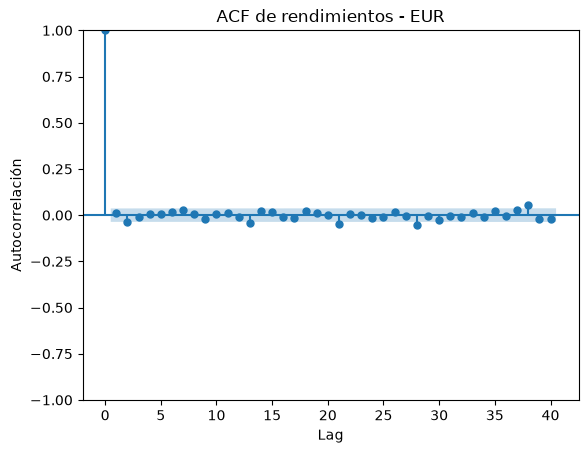

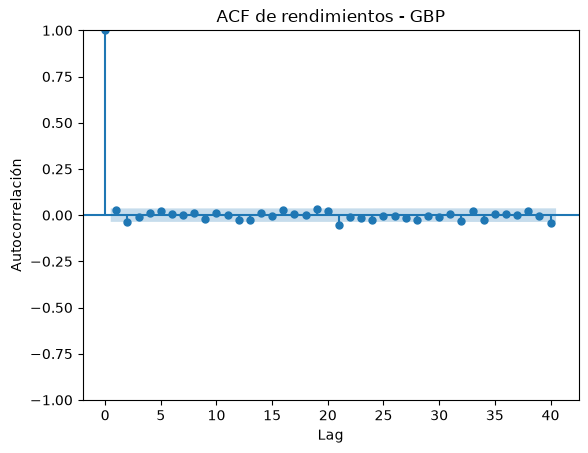

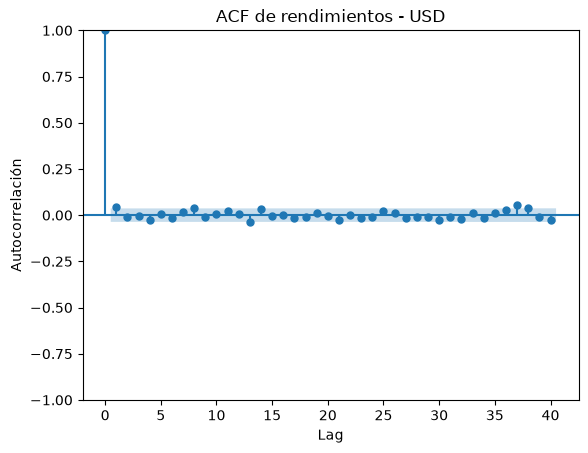

In [55]:
#Ahora Analizaremos la autocorrelación
from statsmodels.graphics.tsaplots import plot_acf

for moneda in ["EUR", "GBP", "USD"]:

    datos = (
        TC.loc[
            TC["tmb_MonedaOrig"] == moneda,
            "Rendimiento"
        ]
        .dropna()
    )

    plot_acf(
        datos,
        lags=40,
        alpha=0.05
    )

    plt.title(f"ACF de rendimientos - {moneda}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelación")
    plt.show()

### Autocorrelación de los rendimientos

Se utilizó la función de autocorrelación (**ACF**) para analizar la relación entre los rendimientos actuales y sus valores pasados hasta un máximo de **40 rezagos**.

Los resultados muestran que, para **EUR, GBP y USD**, la mayoría de las autocorrelaciones se encuentran cercanas a cero y no se observa un patrón persistente a través de los diferentes rezagos.

Aunque algunos rezagos presentan pequeñas desviaciones, estas no muestran una estructura temporal fuerte y consistente.

Lo cual es consistente con las bajas correlaciones observadas previamente para los rezagos de 1, 5 y 20 días.

#### Ahora revisaremos la estacionalidad

In [56]:
#Obtenemos el día de la semana para cada fecha en el dataset
TC["Dia_Semana"] = TC["tmb_FechaCarga"].dt.day_name()

In [57]:
#Revisaremso si el rendimiento cambia segun el día de la semana
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

rendimiento_dia = (
    TC.groupby(
        ["tmb_MonedaOrig", "Dia_Semana"]
    )["Rendimiento"]
    .mean()
    .unstack()
    .reindex(columns=orden_dias)
)

(rendimiento_dia * 100).round(4)

Dia_Semana,Monday,Tuesday,Wednesday,Thursday,Friday
tmb_MonedaOrig,,,,,
EUR,-0.0033,0.0359,-0.0105,0.0495,-0.0767
GBP,-0.0237,0.0279,-0.0080,0.0943,-0.0802
USD,-0.0199,0.0462,-0.0095,0.0378,-0.0702


### Estacionalidad por día de la semana

Se analizaron los rendimientos diarios promedio según el día de la semana con el objetivo de identificar posibles patrones temporales.

Descriptivamente, las tres divisas presentan un comportamiento similar: los rendimientos medios son positivos los **martes y jueves**.

El mayor rendimiento promedio observado corresponde a **GBP los jueves (0.0943%)**, mientras que los viernes presentan valores negativos en las tres divisas.

Estos resultados representan patrones históricos descriptivos y no implican por sí mismos que exista un efecto estadísticamente significativo asociado al día de la semana.

#### Estacionalidad mensual

In [58]:
# Extraemos el mes de cada observación

TC["Mes"] = TC["tmb_FechaCarga"].dt.month

In [59]:
# Rendimiento promedio por mes y divisa

rendimiento_mes = (
    TC.groupby(
        ["tmb_MonedaOrig", "Mes"]
    )["Rendimiento"]
    .mean()
    .unstack()
)

(rendimiento_mes * 100).round(4)


Mes,1,2,3,4,5,6,7,8,9,10,11,12
tmb_MonedaOrig,,,,,,,,,,,,
EUR,0.0204,0.0417,-0.0083,-0.0416,0.0051,0.0051,-0.0030,-0.0506,0.0393,-0.0153,0.0040,-0.0025
GBP,-0.0177,0.0487,-0.0082,-0.0334,0.0077,0.0494,0.0038,-0.0190,0.0281,-0.0329,-0.0372,0.0339
USD,0.0397,-0.0062,-0.0107,-0.0118,0.0078,-0.0026,0.0176,-0.0385,-0.0046,-0.0538,0.0122,0.0151


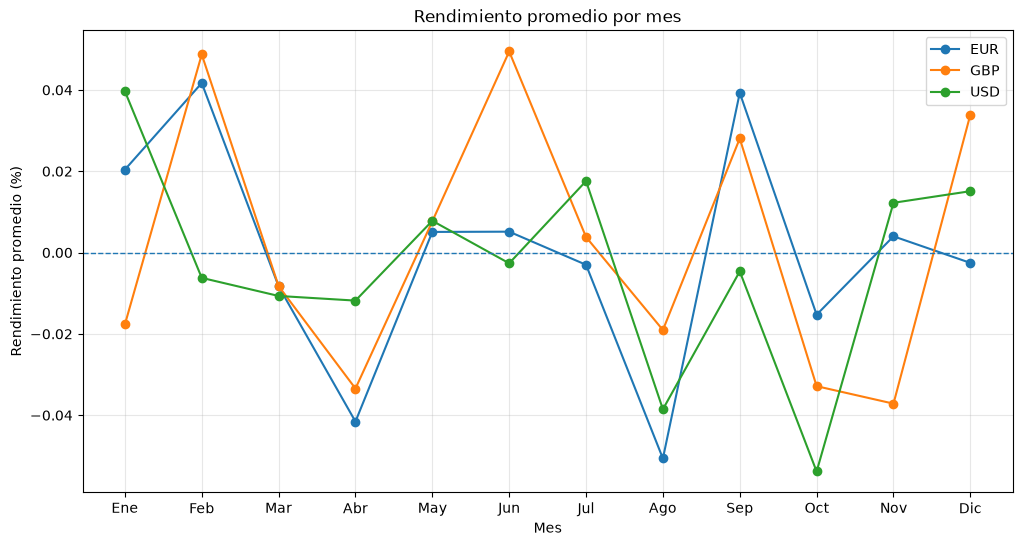

In [60]:
#Ahora graficaremos el rendimiento promedio por mes y divisa
rendimiento_mes_pct = rendimiento_mes * 100

plt.figure(figsize=(12, 6))

for moneda in rendimiento_mes_pct.index:

    plt.plot(
        rendimiento_mes_pct.columns,
        rendimiento_mes_pct.loc[moneda],
        marker="o",
        label=moneda
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Rendimiento promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Rendimiento promedio (%)")

plt.xticks(
    range(1, 13),
    [
        "Ene", "Feb", "Mar", "Abr",
        "May", "Jun", "Jul", "Ago",
        "Sep", "Oct", "Nov", "Dic"
    ]
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Estacionalidad mensual
Se analizaron los rendimientos diarios promedio agrupados por mes con el objetivo de identificar posibles patrones estacionales en **EUR, GBP y USD**.

> * Febrero: EUR y GBP presentan rendimientos promedio positivos relativamente altos.
> * Abril: las tres divisas presentan rendimientos promedio negativos.
> * Mayo: las tres están ligeramente por encima de cero.
> * Agosto: las tres presentan rendimientos promedio negativos.
> * Septiembre: EUR y GBP son positivos, mientras USD permanece ligeramente negativo.
> * Octubre: las tres presentan rendimientos negativos, especialmente USD.
> * No existe un patrón idéntico para las tres monedas durante todos los meses.

Los resultados muestran algunas similitudes entre las tres divisas. Por ejemplo, **abril, agosto y octubre** presentan rendimientos promedio negativos para las tres monedas, mientras que **mayo** presenta rendimientos promedio ligeramente positivos.

También se observan diferencias entre las divisas en determinados meses. Por ejemplo, durante septiembre EUR y GBP presentan rendimientos promedio positivos, mientras que USD permanece ligeramente por debajo de cero

In [61]:
#Calcularemos precentiles para los rendimientos de cada divisa, lo que nos permitirá ver la distribución de los rendimientos y detectar posibles outliers.
regimenes = (
    TC.groupby("tmb_MonedaOrig")["Vola20"]
      .quantile([0.25, 0.75])
      .unstack()
)

regimenes.columns = ["Q25", "Q75"]

regimenes

,Q25,Q75
tmb_MonedaOrig,,
EUR,0.005152,0.008572
GBP,0.005317,0.008742
USD,0.005031,0.008286


In [64]:
# Clasificamos los rendimientos en tres regímenes de volatilidad:
# baja, media y alta, utilizando los percentiles 25 y 75
# calculados de manera independiente para cada divisa.

# Calculamos los límites de volatilidad para cada divisa
TC["Q25_Vola"] = (
    TC.groupby("tmb_MonedaOrig")["Vola20"]
      .transform(lambda x: x.quantile(0.25))
)

TC["Q75_Vola"] = (
    TC.groupby("tmb_MonedaOrig")["Vola20"]
      .transform(lambda x: x.quantile(0.75))
)

# Clasificamos cada observación según su nivel de volatilidad
TC["Regimen_Volatilidad"] = np.select(
    [
        TC["Vola20"] <= TC["Q25_Vola"],
        TC["Vola20"] >= TC["Q75_Vola"]
    ],
    [
        "Baja",
        "Alta"
    ],
    default="Media"
)

# Las observaciones sin Vola20 permanecen sin clasificación
TC.loc[
    TC["Vola20"].isna(),
    "Regimen_Volatilidad"
] = np.nan

In [65]:
TC.columns

Index(['tmb_FechaCarga', 'tmb_MonedaDest', 'tmb_MonedaOrig',
       'tmb_PrecioLimpio', 'Rendimiento', 'Vola20', 'Rendimiento_Abs',
       'Direccion', 'Media_Movil_20', 'Media_Movil_60', 'Lag_1', 'Lag_5',
       'Lag_20', 'Dia_Semana', 'Mes', 'Q25_Vola', 'Q75_Vola',
       'Regimen_Volatilidad'],
      dtype='str')

In [70]:
TC.groupby(
    ["tmb_MonedaOrig", "Regimen_Volatilidad"]
).size()

tmb_MonedaOrig  Regimen_Volatilidad
EUR             Alta                    722
                Baja                    722
                Media                  1441
GBP             Alta                    722
                Baja                    722
                Media                  1441
USD             Alta                    722
                Baja                    722
                Media                  1441
dtype: int64

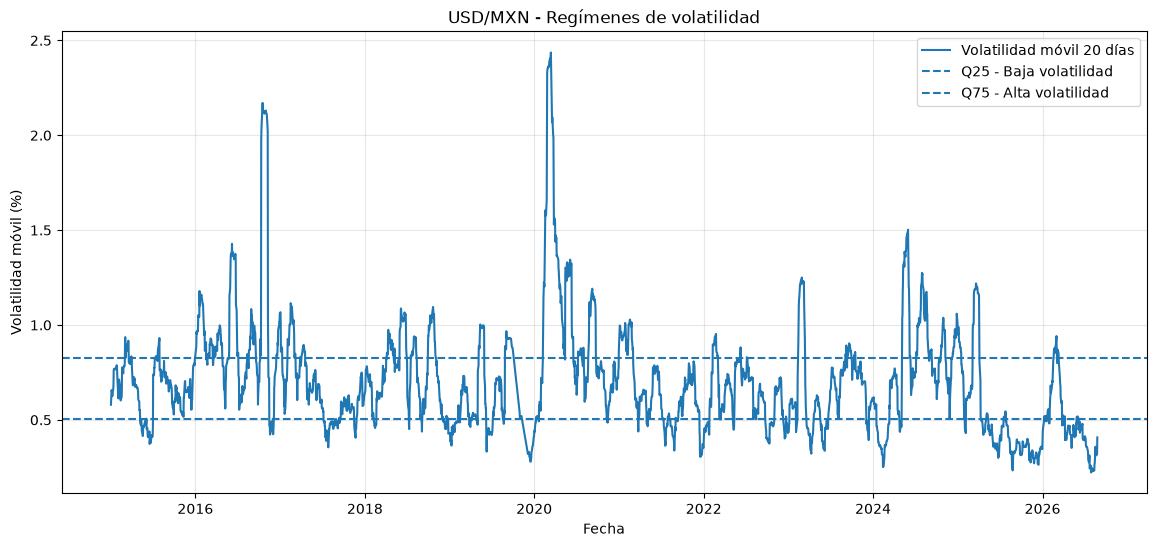

In [71]:
#Ahora graficaremos la volatilidad para USD
# Seleccionamos USD
usd = TC[
    TC["tmb_MonedaOrig"] == "USD"
].copy()

plt.figure(figsize=(14, 6))

# Volatilidad móvil
plt.plot(
    usd["tmb_FechaCarga"],
    usd["Vola20"] * 100,
    label="Volatilidad móvil 20 días"
)

# Límites de los regímenes
plt.axhline(
    usd["Q25_Vola"].iloc[0] * 100,
    linestyle="--",
    label="Q25 - Baja volatilidad"
)

plt.axhline(
    usd["Q75_Vola"].iloc[0] * 100,
    linestyle="--",
    label="Q75 - Alta volatilidad"
)

plt.title("USD/MXN - Regímenes de volatilidad")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad móvil (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [74]:
#Ahora busquemos periodos altos de volatilidad para cada divisa
usd.loc[
    usd["Regimen_Volatilidad"] == "Alta",
    [
        "tmb_FechaCarga",
        "Vola20",
        "Rendimiento"
    ]
].sort_values(
    "Vola20",
    ascending=False
).head(10)

,tmb_FechaCarga,Vola20,Rendimiento
4928,2020-03-13,0.024362,-0.052766
4931,2020-03-12,0.024069,-0.009829
4934,2020-03-11,0.024068,-0.014913
4940,2020-03-09,0.024033,0.009449
4937,2020-03-10,0.023952,-0.022825
4943,2020-03-06,0.023847,-0.041291
4946,2020-03-05,0.023681,-0.014274
4949,2020-03-04,0.023652,-0.016793
4955,2020-03-02,0.023619,0.006367
4952,2020-03-03,0.023580,-0.008029


In [75]:

top_volatilidad_usd = (
    usd.loc[
        usd["Regimen_Volatilidad"] == "Alta",
        ["tmb_FechaCarga", "Vola20", "Rendimiento"]
    ]
    .sort_values("Vola20", ascending=False)
    .head(10)
    .copy()
)

top_volatilidad_usd["Vola20_%"] = (
    top_volatilidad_usd["Vola20"] * 100
).round(3)

top_volatilidad_usd["Rendimiento_%"] = (
    top_volatilidad_usd["Rendimiento"] * 100
).round(3)

top_volatilidad_usd[
    ["tmb_FechaCarga", "Vola20_%", "Rendimiento_%"]
]

,tmb_FechaCarga,Vola20_%,Rendimiento_%
4928,2020-03-13,2.436,-5.277
4931,2020-03-12,2.407,-0.983
4934,2020-03-11,2.407,-1.491
4940,2020-03-09,2.403,0.945
4937,2020-03-10,2.395,-2.283
4943,2020-03-06,2.385,-4.129
4946,2020-03-05,2.368,-1.427
4949,2020-03-04,2.365,-1.679
4955,2020-03-02,2.362,0.637
4952,2020-03-03,2.358,-0.803


### Cambios de régimen de volatilidad

Para identificar cambios en el comportamiento de la volatilidad se utilizó la desviación estándar móvil de **20 días (Vola20)**.

Los regímenes se definieron utilizando los percentiles **25 y 75** de la distribución histórica de volatilidad de cada divisa:

- **Baja volatilidad:** Vola20 ≤ Q25.
- **Volatilidad media:** Q25 < Vola20 < Q75.
- **Alta volatilidad:** Vola20 ≥ Q75.

En el caso de **USD/MXN**, se observan periodos claramente diferenciados de baja, media y alta volatilidad. Además, los episodios de alta volatilidad tienden a concentrarse temporalmente, lo cual es consistente con el fenómeno de **volatility clustering** observado previamente.

El periodo con mayor volatilidad móvil se concentra alrededor de **marzo de 2020**, alcanzando aproximadamente **2.44%**. El 13 de marzo de 2020 se observó además un rendimiento diario de aproximadamente **-5.28%**.

